# Discussion 2: Pandas Group Work

Now that you've tested your knowledge on the practice worksheet, it's time to actually use that knowledge on real data. We will be using the California `babynames` data from lecture.

The following are 5 tasks that are relatively complex, especially compared to what you just did on the worksheet. Form groups of 3 or 4, and choose one task to complete as a group. Discuss best strategies to accomplish the task (in terms of code efficiency, conciseness, etc.) Do not hesitate to Google for help (either to look at the Pandas documentation or StackExchange). 

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
# loading up the California baby names data

import urllib.request
import os.path
import zipfile

data_url = "https://www.ssa.gov/oact/babynames/state/namesbystate.zip"
local_filename = "babynamesbystate.zip"
if not os.path.exists(local_filename): # if the data exists don't download again
    with urllib.request.urlopen(data_url) as resp, open(local_filename, 'wb') as f:
        f.write(resp.read())

zf = zipfile.ZipFile(local_filename, 'r')

ca_name = 'STATE.CA.TXT'
field_names = ['State', 'Sex', 'Year', 'Name', 'Count']
with zf.open(ca_name) as fh:
    babynames = pd.read_csv(fh, header=None, names=field_names)

babynames

,State,Sex,Year,Name,Count
0,CA,F,1910,Mary,295
1,CA,F,1910,Helen,239
2,CA,F,1910,Dorothy,220
3,CA,F,1910,Margaret,163
4,CA,F,1910,Frances,134
...,...,...,...,...,...
407423,CA,M,2022,Zayvier,5
407424,CA,M,2022,Zia,5
407425,CA,M,2022,Zora,5
407426,CA,M,2022,Zuriel,5


## Task 1

There's over 20,000 unique names in this dataset. However, some have been used for longer periods of time than others. Create a `pandas` `DataFrame` where the index is the name, and there are three columns: one corresponding to the first year in which that name appeared in the dataset, and the other corresponding to the last year in which it appeared. Add a third column corresponding to the longevity of the name (how many years it's been used), and arrange the table by decreasing longevity, and display only the first 10 names.

This is what the resulting DataFrame should look like:

*Hint: May require more than one line of code.*

<img src = "(new)_groupwork_q1.png" width = "250">

*Answer:*

In [5]:
b1 = babynames.groupby('Name')['Year'].agg(['min', 'max'])
b1['Longevity'] = b1['max'] - b1['min']
b1.sort_values('Longevity', ascending=False).head(10)

,min,max,Longevity
Name,,,
Madeline,1910,2022,112
Mabel,1910,2022,112
Mae,1910,2022,112
Samuel,1910,2022,112
Eileen,1910,2022,112
Edith,1910,2022,112
Gene,1910,2022,112
Geneva,1910,2022,112
Genevieve,1910,2022,112


## Task 2

Of the unique names given in different years, what proportion of them start with a vowel? Write `pandas` code to return a `pandas` `Series` with the index as the year and the value as the proportion of different names given that year that start with a vowel.

*Hint: the `str.startswith()` method for a Pandas series may be useful to you. You may also find it useful to define a function to plug into to the `agg` method for `groupby` objects, as in lecture.*

This is what the resulting `Series` should look like:

<img src = "groupwork_q2.png" width = "300">

*Answer*: 

In [20]:
babynames['Vowel'] = babynames['Name'].str.startswith(('A', 'E', 'I', 'O', 'U'))
b2 = babynames.groupby('Year')['Vowel'].agg('mean')
b2

Year
1910    0.225895
1911    0.239186
1912    0.236559
1913    0.230016
1914    0.229577
          ...   
2018    0.251412
2019    0.255978
2020    0.256938
2021    0.259508
2022    0.260289
Name: Vowel, Length: 113, dtype: float64

## Task 3

Are names becoming more unique over time? Return a `pandas` `Series` whose index is the `Year` and whose values are the number of names given that year whose count is less than 15. We have provided code that plots the series for you so you can look at the trends.

The resulting plot should look as follows:

<img src = "q3_plot.png" width = "500">

*Answer*:

Text(0, 0.5, 'Count')

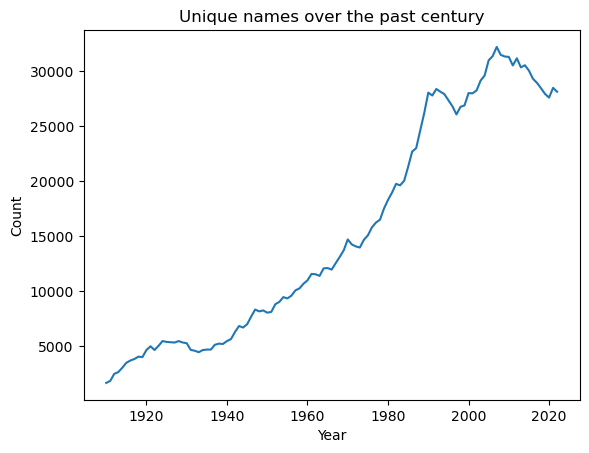

In [23]:
b3 = babynames[babynames['Count'] < 15]
names = b3.groupby('Year')['Count'].agg('sum')

# NO NEED TO MODIFY
plt.plot(names)
plt.title('Unique names over the past century')
plt.xlabel('Year')
plt.ylabel('Count')

## Task 4



Among names that were very popular (let's say, have a count greater than 1000), how many different names are there across sex and year? Write Pandas code that returns a Pandas `DataFrame`, whose columns correspond to sex and whose row indices correspond to year. Each entry should be the number of unique, "popular" names for that year for that sex (given our definition of popular from above).

If there's a `NaN` value (missing value) in the table, why do you think it's there? What do you think is a reasonable value to impute into these missing values? Fill in all missing values with the value your group finds most appropriate (look for the `fillna()` method for pandas dataframes online for info on how to do this)

Hint: Prior to dropping NaN values, this is what your `DataFrame` should look like:

<img src = "groupwork_q4.png" width = "150">

*Answer:*